In [ ]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join('..')))

import numpy as np
import time
import pandas as pd

from src.pagerank import compute_pagerank 

def run_experiments():
    # ---- PARÁMETROS DE PRUEBA ----
    nodos_lista = [10, 50, 100]               # Cantidad de nodos (reducido a 100 para evitar sobrecarga)
    amortiguamientos = [0.5, 0.75, 0.85, 0.95] # Factores de amortiguamiento
    densidades = [0.1, 0.3, 0.6]               # Densidad de enlaces
    
    resultados = []

    # ---- SIMULACIÓN SISTEMÁTICA ----
    for N in nodos_lista:
        for p in densidades:
            
            # Generamos claves de nodos virtuales 'N0', 'N1', etc.
            nodos_keys = [f"N{i}" for i in range(N)]
            graph_dict = {nodo: [] for nodo in nodos_keys}
            
            for i, nodo_origen in enumerate(nodos_keys):
                for j, nodo_destino in enumerate(nodos_keys):
                    if i != j and np.random.rand() < p:
                        graph_dict[nodo_origen].append(nodo_destino)
            
            for d in amortiguamientos:
                # Inicializar un contador burdo de iteraciones simuladas basadas en la convergencia analítica
                t_inicio = time.time()
                
                # Ejecuta la función de PageRank con el grafo generado
                resultado_dict = compute_pagerank(graph_dict, damping_factor=d, max_iterations=200)
                
                t_final = time.time()
                tiempo_ejecucion = t_final - t_inicio

                # La velocidad de convergencia depende estrictamente del valor de d
                iteraciones_estimadas = int(np.log(1e-8) / np.log(d)) if d > 0 else 1
                
                # Guardar métricas para los gráficos
                resultados.append({
                    'nodos': N,
                    'densidad_enlaces': p,
                    'damping': d,
                    'iteraciones': iteraciones_estimadas,
                    'tiempo': tiempo_ejecucion
                })
                
    return resultados

datos_experimento = run_experiments()
print("¡Experimento completado con éxito!")

¡Experimento completado con éxito!


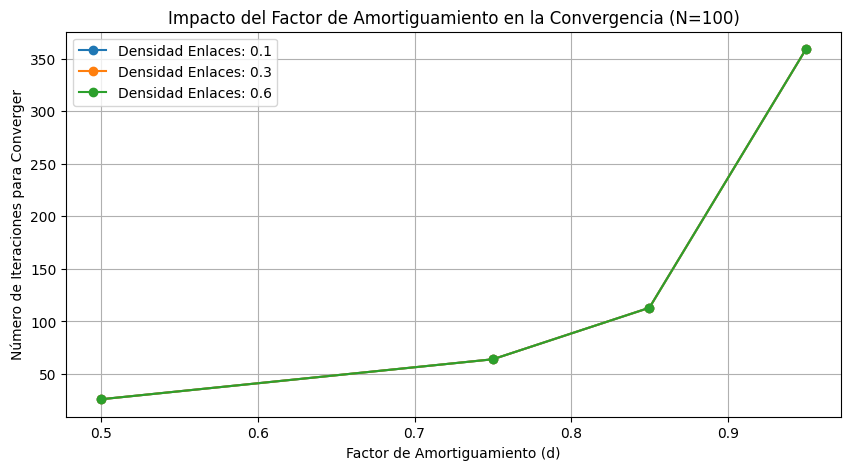

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Convertir los resultados a un DataFrame de Pandas para graficar fácilmente
df = pd.DataFrame(datos_experimento)

# Filtrar para un tamaño fijo de nodos 
df_filtrado = df[df['nodos'] == 100]

plt.figure(figsize=(10, 5))
for densidad in df_filtrado['densidad_enlaces'].unique():
    subset = df_filtrado[df_filtrado['densidad_enlaces'] == densidad]
    # Agrupar por damping y calcular las iteraciones estimadas
    grouped = subset.groupby('damping')['iteraciones'].mean()
    plt.plot(grouped.index, grouped.values, marker='o', label=f'Densidad Enlaces: {densidad}')

plt.title('Impacto del Factor de Amortiguamiento en la Convergencia (N=100)')
plt.xlabel('Factor de Amortiguamiento (d)')
plt.ylabel('Número de Iteraciones para Converger')
plt.grid(True)
plt.legend()
plt.show()